/content/cleaning_01.py:134: SyntaxWarning: invalid escape sequence '\D'
  print("\Duplicates:")


Using Colab cache for faster access to the 'ames-housing-dataset' dataset.
Path to dataset files: /kaggle/input/ames-housing-dataset


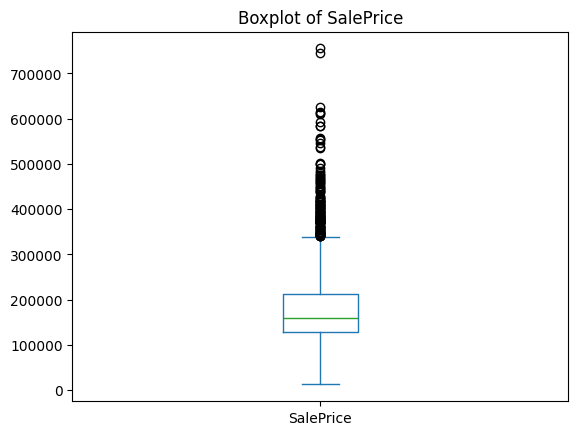

Shape:
(2930, 82)
Info:
Shape: (2930, 82)
Info before fixing types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   objec

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import kagglehub
from cleaning_01 import clean_data
import kagglehub

path = kagglehub.dataset_download("prevek18/ames-housing-dataset")
df = pd.read_csv(path + "/AmesHousing.csv")
df


# .One-Hot Encode



Applies one-hot encoding to selected categorical columns and returns the updated DataFrame.  


In [ ]:
def one_hot_encode(df):
    cols = ["Lot Shape", "House Style"]
    df = pd.get_dummies(df, columns=cols, drop_first=True)
    return df

# Ordinal Encode


Encodes the "Kitchen Qual" column by mapping ordered categories to numerical values and returns the updated DataFrame.  


In [ ]:
def ordinal_encode(df):
    qual_map = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
    df["Kitchen Qual"] = df["Kitchen Qual"].map(qual_map)
    return df

# • Scale



Scales selected numerical features using StandardScaler by fitting on training data and applying the same transformation to test data, then returns both datasets.  


In [ ]:
def scale_features(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    scaler = StandardScaler()
    scale_cols = ["Gr Liv Area", "Lot Area"]

    train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
    test_df[scale_cols] = scaler.transform(test_df[scale_cols])

    return train_df, test_df

# 2 Domain Features

Creates new domain features by calculating price per square foot and total area, then returns the updated DataFrame.  


In [ ]:
def domain_feature(df):
    df["Price_per_Sqft"] = df["SalePrice"] / df["Gr Liv Area"].replace(0, np.nan)
    df["TotalArea"] = df["Gr Liv Area"] + df["Total Bsmt SF"]
    return df

# 1 Interaction Feature



Creates a new feature by multiplying overall quality with living area to capture their interaction, then returns the updated DataFrame.  


In [ ]:
def interaction_feature(df):
    df["quality_x_area"] = df["Overall Qual"] * df["Gr Liv Area"]
    return df


# log_transfrom

Applies a log transformation to "Gr Liv Area" to reduce skewness, visualizes before and after with histograms, and returns the updated DataFrame.  


In [ ]:
def log_transform(df):


    plt.figure(figsize = (6, 4))
    plt.hist(df["Gr Liv Area"], bins = 30)
    plt.title("Gr Liv Area Before Log Transform")
    plt.xlabel("Gr Liv Area")
    plt.ylabel("Count")
    plt.show()

    df["Gr Liv Area Log"] = np.log1p(df["Gr Liv Area"])

    plt.figure(figsize = (6, 4))
    plt.hist(df["Gr Liv Area Log"], bins = 30)
    plt.title("Gr Liv Area After Log Transform")
    plt.xlabel("Gr Liv Area Log")
    plt.ylabel("Count")
    plt.show()

    return df

# Bin



Creates a new feature "House Age" and bins it into age groups ("New", "Recent", "Old"), then returns the updated DataFrame.  


In [ ]:
def binning_feature(df):
    df = df.copy()

    df["House Age"] = 2026 - df["Year Built"]

    df["Age Group"] = pd.cut(
        df["House Age"],
        bins = [0, 20, 50, 200],
        labels = ["New", "Recent", "Old"]
    )

    return df

.Train Test Split

Splits the DataFrame into training and testing sets (80% train, 20% test) and returns both.  


In [ ]:
def split_data(df):
    train_df, test_df = train_test_split(df, test_size = 0.2, random_state = 42)
    return train_df, test_df

# Remove Redundant Features



Removes highly correlated (redundant) features with correlation above 0.95 from training and testing sets, then returns the cleaned datasets and list of dropped columns.  


In [ ]:
def  remove_Redundant_Features(train_df, test_df):
    corr = train_df.corr(numeric_only=True).abs()

    to_drop = []
    for col in corr.columns:
        for row in corr.index:
            if col != row and corr.loc[row, col] > 0.95:
                if col not in to_drop:
                    to_drop.append(col)

    train_df = train_df.drop(columns=to_drop, errors="ignore")
    test_df = test_df.drop(columns=to_drop, errors="ignore")

    return train_df, test_df, to_drop

#clean data

Cleans and preprocesses the dataset by applying one-hot and ordinal encoding, creating domain and interaction features, log transformation, binning, splitting, scaling, and removing redundant features, then returns the training and testing sets.  


In [ ]:
def clean_data2(path):
    df = clean_data(path)
    df_1 = one_hot_encode(df)
    df_2 = ordinal_encode(df)
    df_3 = domain_feature(df)
    df_3 = interaction_feature(df)
    df_4 = log_transform(df)
    df_5 = binning_feature(df)

    train_df, test_df = split_data(df)
    train_df, test_df = scale_features(train_df, test_df)

    train_df, test_df, dropped_cols = remove_Redundant_Features(train_df, test_df)

    features_df = pd.concat([train_df, test_df]).sort_index()

    print("Dropped columns:", dropped_cols)
    print("Final shape:", features_df.shape)

    return train_df, test_df


Shape before cleaning: (2930, 82)
Number of duplicates: 0
Shape after cleaning: (2930, 82)


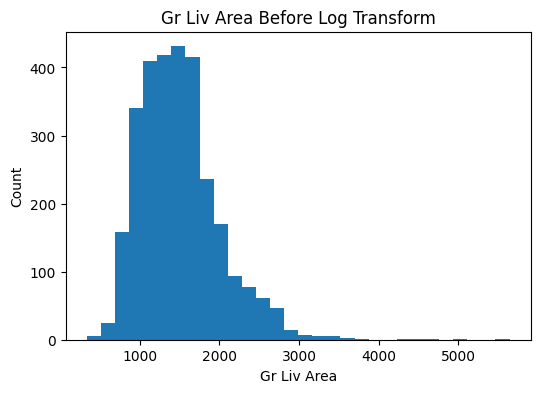

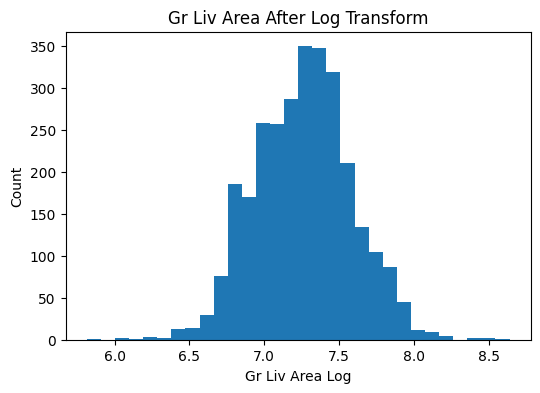

Dropped columns: ['Order', 'Gr Liv Area', 'Yr Sold', 'Gr Liv Area Log']
Final shape: (2930, 82)
(            PID MS SubClass MS Zoning  Lot Frontage  Lot Area Street    Alley  \
381   527359050          20        RL          80.0  0.033810   Pave  Unknown   
834   906475070          60        RL          68.0  2.307082   Pave  Unknown   
1898  534429030          90        RL          70.0 -0.035514   Pave  Unknown   
678   535451170          90        RL          60.0 -0.363746   Pave  Unknown   
700   902109130         190        RM          63.0 -0.310697   Pave  Unknown   
...         ...         ...       ...           ...       ...    ...      ...   
1638  527226040         190        RL         195.0  3.909976   Pave  Unknown   
1095  528290090          60        RL          68.0 -0.295416   Pave  Unknown   
1130  528490080          60        FV          64.0 -0.166086   Pave  Unknown   
1294  902109160          50        RM          81.0 -0.350328   Pave  Unknown   
860   907227

In [ ]:
path1 = "/content/AmesHousing.csv"
print(clean_data2(path1))